In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from concurrent.futures import ThreadPoolExecutor
from datetime import date

import cma
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import kge, mkge, nse, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.parameters_running_rakican import (
    rakican_curve_number,
    rakican_groundwater,
    rakican_initial_cond,
    rakican_maize_params,
    rakican_management,
    rakican_readily_evaporable_water,
    rakican_soil_layers,
)
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison
from aquacrop_slovenia.reading_data import (
    get_co2_for_aquacrop,
    get_station_weather,
    get_yield,
    get_yield_for_comparison,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "rakican"
K_FOLDS = 5
MAX_WORKERS = os.cpu_count()

ALL_YEARS = [y for y in range(1993, 2024) if y not in {1998, 2023, 2017}]
print(f"Total years: {len(ALL_YEARS)}  ({ALL_YEARS[0]}\u2013{ALL_YEARS[-1]}, excluding 1998, 2017, 2023)")

temperatures, eto, rain = get_station_weather(355)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} soil",
    soil_layers=rakican_soil_layers,
    curve_number=rakican_curve_number,
    readily_evaporable_water=rakican_readily_evaporable_water,
)

observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in rakican_maize_params.items() if isinstance(val, int)}
print(f"Observed grain years: {sorted(observed_grain['year'].tolist())}")

Total years: 28  (1993–2022, excluding 1998, 2017, 2023)
Observed grain years: [1993, 1994, 1995, 1996, 1997, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022]


In [4]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.MODEL_RUNNING_DIR / f"cmaes_rakican_kfold_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories ready: {MAX_WORKERS}")

Worker directories ready: 28


In [5]:
param_names = [
    "harvest_index",
    "gdd_senescence",
    "gdd_flowering",
    "gdd_flowering_length",
    "max_canopy_cover",
    "cgc_gdd",
    #"cdc_gdd",
    "ksat",
    "min_rooting_depth",
    "max_rooting_depth",
    "p_upper_senescence",
    "p_upper_stomata"
]

bounds = [
    (0.46, 0.6),   # harvest_index
    (1000, 1150),   # gdd_senescence
    (480,  530),    # gdd_flowering
    (130,  170),    # gdd_flowering_length
    (0.85, 0.97),   # max_canopy_cover
    (0.005, 0.03),  # cgc_gdd
    #(0.005, 0.02),  # cdc_gdd
    (5, 3000),      # ksat
    (0.1, 0.4),     # min_rooting_depth
    (0.5, 2.5),     # max_rooting_depth
    (0.4, 0.8),     # p_upper_senescence
    (0.4, 0.8),     # p_upper_stomata
]

lower = np.array([b[0] for b in bounds])
upper = np.array([b[1] for b in bounds])
x0 = (lower + upper) / 2.0

print(f"Parameters: {param_names}")
print(f"x0:         {x0}")

Parameters: ['harvest_index', 'gdd_senescence', 'gdd_flowering', 'gdd_flowering_length', 'max_canopy_cover', 'cgc_gdd', 'ksat', 'min_rooting_depth', 'max_rooting_depth', 'p_upper_senescence', 'p_upper_stomata']
x0:         [5.3000e-01 1.0750e+03 5.0500e+02 1.5000e+02 9.1000e-01 1.7500e-02
 1.5025e+03 2.5000e-01 1.5000e+00 6.0000e-01 6.0000e-01]


In [6]:
years_array = np.array(ALL_YEARS)
kf = KFold(n_splits=K_FOLDS, shuffle=False)

folds = []
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(years_array)):
    train_years = years_array[train_idx].tolist()
    test_years  = years_array[test_idx].tolist()
    folds.append({"train": train_years, "test": test_years})
    print(f"Fold {fold_idx+1}: train={train_years}  |  test={test_years}")

Fold 1: train=[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022]  |  test=[1993, 1994, 1995, 1996, 1997, 1999]
Fold 2: train=[1993, 1994, 1995, 1996, 1997, 1999, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022]  |  test=[2000, 2001, 2002, 2003, 2004, 2005]
Fold 3: train=[1993, 1994, 1995, 1996, 1997, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022]  |  test=[2006, 2007, 2008, 2009, 2010, 2011]
Fold 4: train=[1993, 1994, 1995, 1996, 1997, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2018, 2019, 2020, 2021, 2022]  |  test=[2012, 2013, 2014, 2015, 2016]
Fold 5: train=[1993, 1994, 1995, 1996, 1997, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]  |  test=[2018, 2019, 2020, 2021, 2022]


In [7]:
def make_simulation_periods(years):
    return [
        {
            "start_date": date(y, 1, 1),
            "end_date":   date(y, 12, 31),
            "planting_date": date(y, 4, 20),
            "is_seeding_year": True,
        }
        for y in years
    ]


def evaluate_params(param_values, sim_periods):
    """Run one candidate on the given simulation periods and return grain metrics."""
    working_dir = dir_queue.get()
    try:
        crop_params = copy.deepcopy(rakican_maize_params)
        current_ksat = None

        for name, val in zip(param_names, param_values):
            if name == "ksat":
                current_ksat = float(val)
            else:
                crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="cma-es-kfold",
            params=crop_params,
        )

        if current_ksat is not None:
            modified_layers = copy.deepcopy(rakican_soil_layers)
            for layer in modified_layers:
                layer.ksat = current_ksat
            current_soil = Soil(
                name=f"{LOCATION} soil",
                description="kfold-ksat",
                soil_layers=modified_layers,
                curve_number=rakican_curve_number,
                readily_evaporable_water=rakican_readily_evaporable_water,
            )
        else:
            current_soil = soil

        simulation = AquaCrop(
            simulation_periods=sim_periods,
            crop=crop,
            soil=current_soil,
            management=rakican_management,
            initial_conditions=rakican_initial_cond,
            climate=weather,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_result = {"grain_rmse": np.nan, "grain_nse": np.nan, "grain_kge": np.nan, "grain_mkge": np.nan}

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return nan_result

        seasonal = results["season"][["Year1", "Y(dry)"]].rename(
            columns={"Year1": "year", "Y(dry)": "grain_modeled"}
        )
        merged = observed_grain.merge(seasonal, on="year")
        if merged.empty:
            return nan_result

        y_obs = merged["yield"].values
        y_mod = merged["grain_modeled"].values
        return {
            "grain_rmse": root_mean_squared_error(y_obs, y_mod),
            "grain_nse":  nse(y_mod, y_obs),
            "grain_kge":  kge(y_mod, y_obs),
            "grain_mkge": mkge(y_mod, y_obs),
        }
    finally:
        dir_queue.put(working_dir)

In [ ]:
SIGMA0 = 0.3
default_popsize = 4 + int(3 * np.log(len(param_names)))
POPSIZE = max(MAX_WORKERS, default_popsize)

CMAES_OPTIONS = {
    "bounds": [lower.tolist(), upper.tolist()],
    "CMA_stds": (upper - lower).tolist(),  # scale sigma0 per-coordinate to each param's own range
    "popsize": POPSIZE,
    "maxiter": 40,
    "tolx": 1e-5,
    "tolfun": 1e-5,
    "seed": 43,
    "verbose": -9,
}

print(f"Cores: {MAX_WORKERS}  |  popsize: {POPSIZE}")

In [9]:
def run_fold(fold_idx, train_years, test_years):
    """Fit CMA-ES on train_years, evaluate on train and test. Returns a result dict."""
    train_periods = make_simulation_periods(train_years)
    test_periods  = make_simulation_periods(test_years)

    def objective(param_values):
        r = evaluate_params(param_values, train_periods)
        return -r["grain_mkge"] if np.isfinite(r["grain_mkge"]) else 1e6

    def parallel_evaluate(solutions):
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            return list(executor.map(objective, solutions))

    es = cma.CMAEvolutionStrategy(x0, SIGMA0, CMAES_OPTIONS)
    convergence = []
    while not es.stop():
        solutions = es.ask()
        fitnesses = parallel_evaluate(solutions)
        penalty = max((f for f in fitnesses if np.isfinite(f)), default=1e6) * 10
        fitnesses = [penalty if not np.isfinite(f) else f for f in fitnesses]
        es.tell(solutions, fitnesses)
        convergence.append((es.result.iterations, es.result.fbest))

    xbest = es.result.xbest

    train_metrics = evaluate_params(xbest, train_periods)
    test_metrics  = evaluate_params(xbest, test_periods)

    print(
        f"Fold {fold_idx+1}/{K_FOLDS} done \u2014 "
        f"train grain_mkge={train_metrics['grain_mkge']:.4f}  "
        f"test grain_mkge={test_metrics['grain_mkge']:.4f}  "
        f"(iters={es.result.iterations}, evals={es.result.evaluations})"
    )

    return {
        "fold":        fold_idx + 1,
        "train_years": train_years,
        "test_years":  test_years,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"test_{k}":  v for k, v in test_metrics.items()},
        **{f"best_{n}":  v for n, v in zip(param_names, xbest)},
        "iterations":  es.result.iterations,
        "evaluations": es.result.evaluations,
        "convergence": convergence,
    }

In [10]:
print(f"Running {K_FOLDS}-fold cross-validation (objective: grain mKGE) \u2026")
fold_results = []
for fold_idx, fold in enumerate(folds):
    result = run_fold(fold_idx, fold["train"], fold["test"])
    fold_results.append(result)

print("\nAll folds complete.")

Running 5-fold cross-validation (objective: grain mKGE) …
Results successfully parsed


In [21]:
import pickle

pickle.dump(fold_results, open(config.RESULTS_DIR / "cmaes_rakican_kfold2.pkl", "wb"))
print(f"Saved {len(fold_results)} fold results to {config.RESULTS_DIR / 'cmaes_rakican_kfold.pkl'}")

In [22]:
results_df = pd.DataFrame(fold_results).set_index("fold")

metric_cols = ["train_grain_mkge", "train_grain_nse", "train_grain_rmse",
               "test_grain_mkge",  "test_grain_nse",  "test_grain_rmse"]

print("Per-fold metrics:")
display(results_df[metric_cols].round(4))

means = results_df[metric_cols].mean()
stds  = results_df[metric_cols].std()
print("\nMean \u00b1 std across folds:")
for col in metric_cols:
    print(f"  {col}: {means[col]:.4f} \u00b1 {stds[col]:.4f}")

,train_grain_mkge,train_grain_nse,train_grain_rmse,test_grain_mkge,test_grain_nse,test_grain_rmse
fold,,,,,,
1,0.7521,0.4988,1.7091,0.2805,-5.9485,2.2120
2,0.6528,0.3228,1.7633,0.8201,0.6464,1.2926
3,0.6946,0.4034,1.7610,0.6519,0.1966,1.3408
4,0.6425,0.3037,1.8932,0.5338,0.7183,0.8514
5,0.8510,0.6971,0.9891,0.4046,-0.5897,3.8635


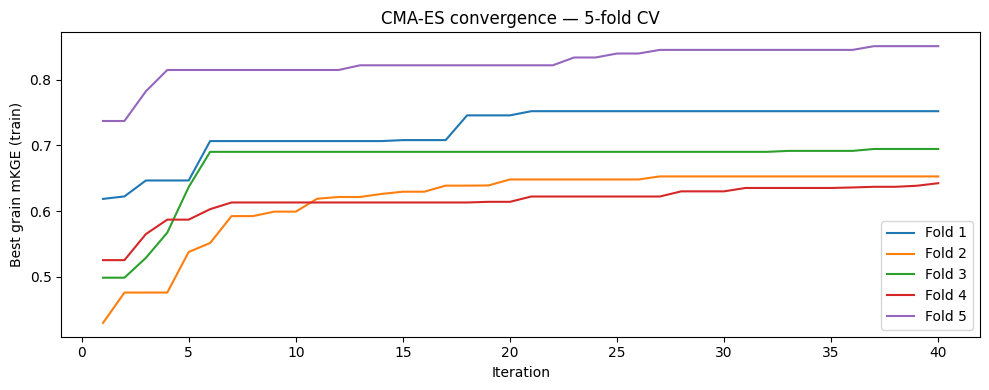

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

for result in fold_results:
    iters, fbest = zip(*result["convergence"])
    mkge_best = [-f for f in fbest]
    ax.plot(iters, mkge_best, label=f"Fold {result['fold']}")

ax.set_xlabel("Iteration")
ax.set_ylabel("Best grain mKGE (train)")
ax.set_title(f"CMA-ES convergence \u2014 {K_FOLDS}-fold CV")
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
best_param_cols = [f"best_{n}" for n in param_names]
print("Best parameters per fold:")
display(results_df[best_param_cols].round(6))

print("\nMean best parameters:")
for col in best_param_cols:
    name = col.replace("best_", "")
    print(f"  {name}: {results_df[col].mean():.6f} \u00b1 {results_df[col].std():.6f}")

,best_harvest_index,best_gdd_senescence,best_gdd_flowering,best_gdd_flowering_length,best_max_canopy_cover,best_cgc_gdd,best_ksat,best_min_rooting_depth,best_max_rooting_depth,best_p_upper_senescence,best_p_upper_stomata
fold,,,,,,,,,,,
1,0.522640,1073.949925,504.528348,150.467718,0.969990,0.015762,1503.282423,0.399970,0.606401,0.773487,0.436059
2,0.596711,1075.098825,504.442625,148.871722,0.965295,0.013059,1503.418246,0.252488,0.639528,0.619010,0.444466
3,0.540004,1075.199941,505.130531,150.803949,0.946549,0.014959,1503.743567,0.143858,0.672915,0.738674,0.400009
4,0.599226,1075.207363,506.233262,149.443864,0.850099,0.013449,1501.719393,0.397326,0.581358,0.643369,0.405819
5,0.475092,1075.415375,504.772786,149.753959,0.868473,0.013654,1502.227718,0.293143,0.916543,0.498479,0.617800


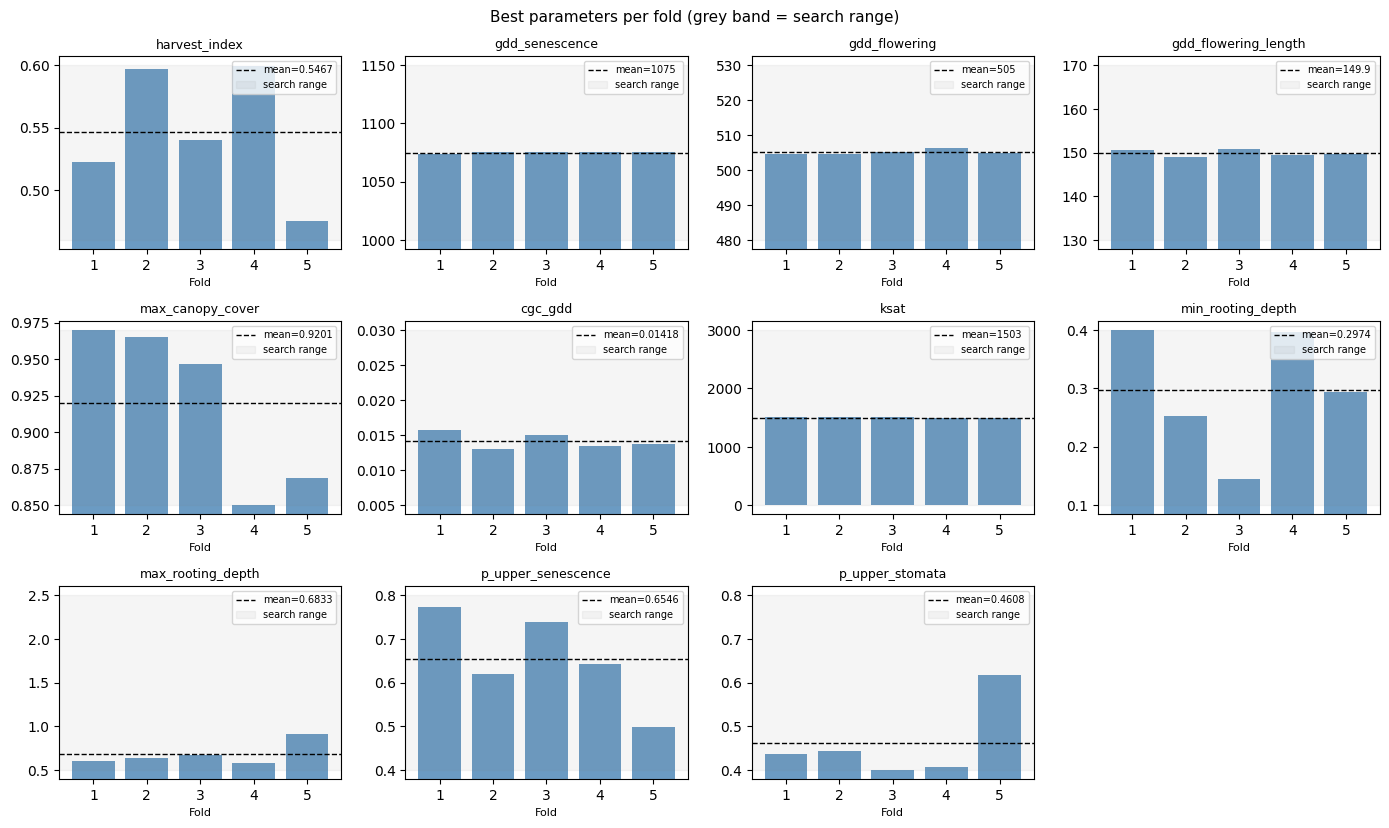

In [25]:
n_params = len(param_names)
ncols = 4
nrows = (n_params + ncols - 1) // ncols

bounds_dict = dict(zip(param_names, bounds))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.8))
axes = axes.flatten()

for i, name in enumerate(param_names):
    col = f"best_{name}"
    vals = results_df[col]
    lo, hi = bounds_dict[name]

    ax = axes[i]
    ax.bar(results_df.index, vals, color="steelblue", alpha=0.8)
    ax.axhline(vals.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={vals.mean():.4g}")
    ax.axhspan(lo, hi, color="grey", alpha=0.08, label="search range")
    ax.set_ylim(lo - 0.05 * (hi - lo), hi + 0.05 * (hi - lo))
    ax.set_title(name, fontsize=9)
    ax.set_xticks(results_df.index)
    ax.set_xlabel("Fold", fontsize=8)
    ax.legend(fontsize=7)

for j in range(n_params, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Best parameters per fold (grey band = search range)", fontsize=11)
plt.tight_layout()
plt.show()

In [26]:
best_param_cols = [f"best_{n}" for n in param_names]
param_stats = pd.DataFrame({
    "lower_bound":  [lo for lo, hi in bounds],
    "upper_bound":  [hi for lo, hi in bounds],
    "mean":   results_df[best_param_cols].mean().values,
    "median": results_df[best_param_cols].median().values,
    "std":    results_df[best_param_cols].std().values,
}, index=param_names)
display(param_stats.round(6))

,lower_bound,upper_bound,mean,median,std
harvest_index,0.460,0.60,0.546734,0.540004,0.052468
gdd_senescence,1000.000,1150.00,1074.974286,1075.199941,0.584087
gdd_flowering,480.000,530.00,505.021511,504.772786,0.728081
gdd_flowering_length,130.000,170.00,149.868242,149.753959,0.777999
max_canopy_cover,0.850,0.97,0.920081,0.946549,0.056561
cgc_gdd,0.005,0.03,0.014176,0.013654,0.001138
ksat,5.000,3000.00,1502.878269,1503.282423,0.861665
min_rooting_depth,0.100,0.40,0.297357,0.293143,0.107373
max_rooting_depth,0.500,2.50,0.683349,0.639528,0.134844
p_upper_senescence,0.400,0.80,0.654604,0.643369,0.108362


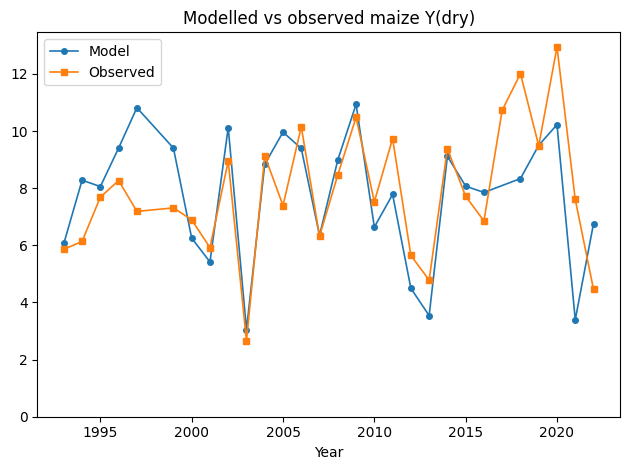

In [27]:
mean_params = param_stats["mean"].values

crop_params_avg = copy.deepcopy(rakican_maize_params)
avg_ksat = None
for name, val in zip(param_names, mean_params):
    if name == "ksat":
        avg_ksat = float(val)
    else:
        crop_params_avg[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

if avg_ksat is not None:
    avg_layers = copy.deepcopy(rakican_soil_layers)
    for layer in avg_layers:
        layer.ksat = avg_ksat
    avg_soil = Soil(
        name=f"{LOCATION} soil",
        description="avg-params",
        soil_layers=avg_layers,
        curve_number=rakican_curve_number,
        readily_evaporable_water=rakican_readily_evaporable_water,
    )
else:
    avg_soil = soil

avg_dir = config.MODEL_RUNNING_DIR / "cmaes_rakican_kfold_avg"
avg_dir.mkdir(parents=True, exist_ok=True)

all_periods = make_simulation_periods(ALL_YEARS)
sim_avg = AquaCrop(
    simulation_periods=all_periods,
    crop=Crop(name=f"{LOCATION} maize", description="kfold-avg", params=crop_params_avg),
    soil=avg_soil,
    management=rakican_management,
    initial_conditions=rakican_initial_cond,
    climate=weather,
    working_dir=avg_dir,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)
with contextlib.redirect_stdout(io.StringIO()):
    seasonal_avg = sim_avg.run()["season"]

plot_yield_timeseries_comparison(seasonal_avg, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)
plt.show()

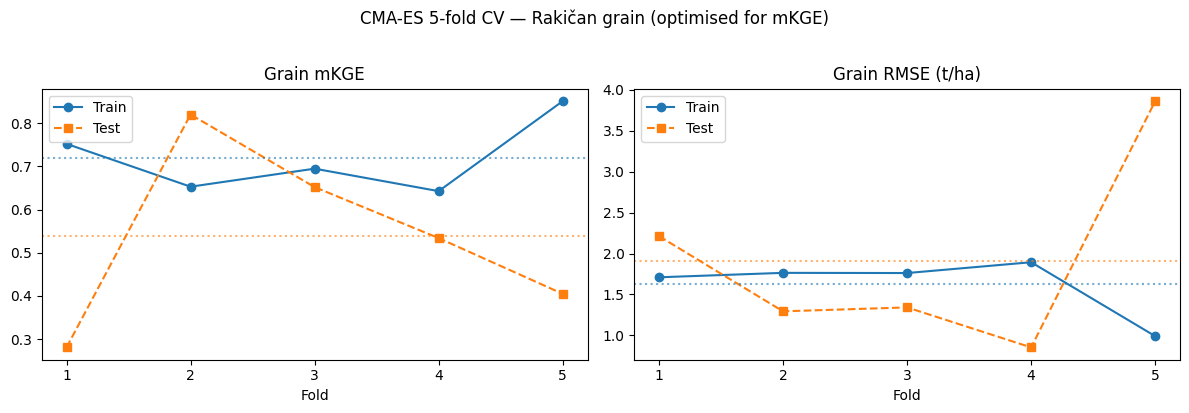

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [
    (axes[0], "grain_mkge", "Grain mKGE"),
    (axes[1], "grain_rmse", "Grain RMSE (t/ha)"),
]:
    ax.plot(results_df.index, results_df[f"train_{metric}"], "o-", label="Train")
    ax.plot(results_df.index, results_df[f"test_{metric}"],  "s--", label="Test")
    ax.axhline(results_df[f"train_{metric}"].mean(), color="C0", linestyle=":", alpha=0.6)
    ax.axhline(results_df[f"test_{metric}"].mean(),  color="C1", linestyle=":", alpha=0.6)
    ax.set_xlabel("Fold")
    ax.set_title(title)
    ax.legend()
    ax.set_xticks(results_df.index)

fig.suptitle(f"CMA-ES {K_FOLDS}-fold CV \u2014 Raki\u010dan grain (optimised for mKGE)", y=1.02)
plt.tight_layout()
plt.show()

In [29]:
all_predictions = []
for row in fold_results:
    xbest = [row[f"best_{n}"] for n in param_names]
    test_periods = make_simulation_periods(row["test_years"])

    crop_params = copy.deepcopy(rakican_maize_params)
    current_ksat = None
    for name, val in zip(param_names, xbest):
        if name == "ksat":
            current_ksat = float(val)
        else:
            crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

    if current_ksat is not None:
        modified_layers = copy.deepcopy(rakican_soil_layers)
        for layer in modified_layers:
            layer.ksat = current_ksat
        current_soil = Soil(
            name=f"{LOCATION} soil",
            description="kfold-pred",
            soil_layers=modified_layers,
            curve_number=rakican_curve_number,
            readily_evaporable_water=rakican_readily_evaporable_water,
        )
    else:
        current_soil = soil

    pred_dir = config.MODEL_RUNNING_DIR / f"cmaes_rakican_kfold_pred_{row['fold']}"
    pred_dir.mkdir(parents=True, exist_ok=True)

    sim = AquaCrop(
        simulation_periods=test_periods,
        crop=Crop(name=f"{LOCATION} maize", description="kfold-pred", params=crop_params),
        soil=current_soil,
        management=rakican_management,
        initial_conditions=rakican_initial_cond,
        climate=weather,
        working_dir=pred_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )
    with contextlib.redirect_stdout(io.StringIO()):
        seasonal = sim.run()["season"][["Year1", "Y(dry)"]].rename(
            columns={"Year1": "year", "Y(dry)": "grain_modeled"}
        )
    seasonal["fold"] = row["fold"]
    all_predictions.append(seasonal)

pred_df = pd.concat(all_predictions).merge(observed_grain, on="year")
print(f"Predictions assembled: {len(pred_df)} years")
pred_df

,year,grain_modeled,fold,yield
0,1993,6.214,1,5.861
1,1994,8.561,1,6.139
2,1995,8.060,1,7.690
3,1996,9.319,1,8.270
4,1997,11.231,1,7.188
5,1999,9.717,1,7.312
6,2000,6.060,2,6.894
7,2001,5.325,2,5.923
8,2002,10.353,2,8.950
9,2003,3.203,2,2.659


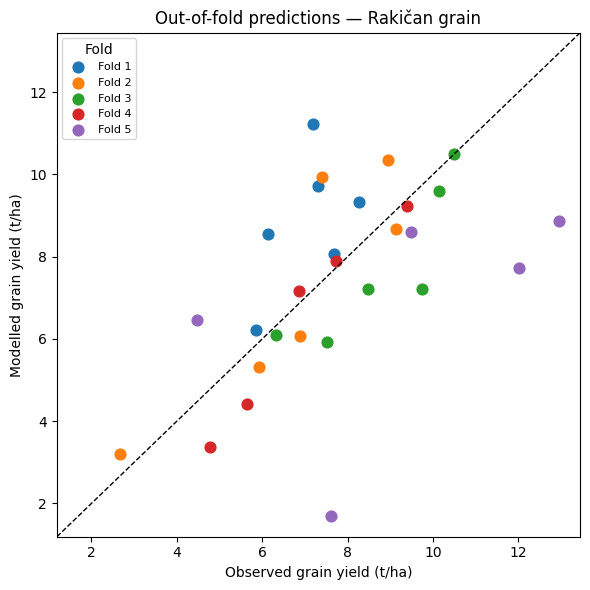

In [30]:
fig, ax = plt.subplots(figsize=(6, 6))

for fold_id, grp in pred_df.groupby("fold"):
    ax.scatter(grp["yield"], grp["grain_modeled"], label=f"Fold {fold_id}", s=60)

lim = [pred_df[["yield", "grain_modeled"]].min().min() - 0.5,
       pred_df[["yield", "grain_modeled"]].max().max() + 0.5]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Observed grain yield (t/ha)")
ax.set_ylabel("Modelled grain yield (t/ha)")
ax.set_title("Out-of-fold predictions \u2014 Raki\u010dan grain")
ax.legend(title="Fold", fontsize=8)
plt.tight_layout()
plt.show()

overall_mkge = mkge(pred_df["grain_modeled"].values, pred_df["yield"].values)
overall_rmse = root_mean_squared_error(pred_df["yield"].values, pred_df["grain_modeled"].values)
print(f"Overall out-of-fold mKGE: {overall_mkge:.4f}")
print(f"Overall out-of-fold RMSE: {overall_rmse:.4f} t/ha")